In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('london_energy.csv')
df

,LCLid,Date,KWH
0,MAC000002,2012-10-12,7.098
1,MAC000002,2012-10-13,11.087
2,MAC000002,2012-10-14,13.223
3,MAC000002,2012-10-15,10.257
4,MAC000002,2012-10-16,9.769
...,...,...,...
3510428,MAC005567,2014-02-24,4.107
3510429,MAC005567,2014-02-25,5.762
3510430,MAC005567,2014-02-26,5.066
3510431,MAC005567,2014-02-27,3.217


In [57]:
print(df.isna().sum())

LCLid    0
Date     0
KWH      0
dtype: int64


In [58]:
df_avg_consumption = df.groupby("Date")["KWH"].mean()
df_avg_consumption = pd.DataFrame({"date": df_avg_consumption.index.tolist(), "consumption": df_avg_consumption.values.tolist()})
df_avg_consumption["date"] = pd.to_datetime(df_avg_consumption["date"])
print(f"From: {df_avg_consumption['date'].min()}")
print(f"To: {df_avg_consumption['date'].max()}")

From: 2011-11-23 00:00:00
To: 2014-02-28 00:00:00


<Axes: xlabel='date'>

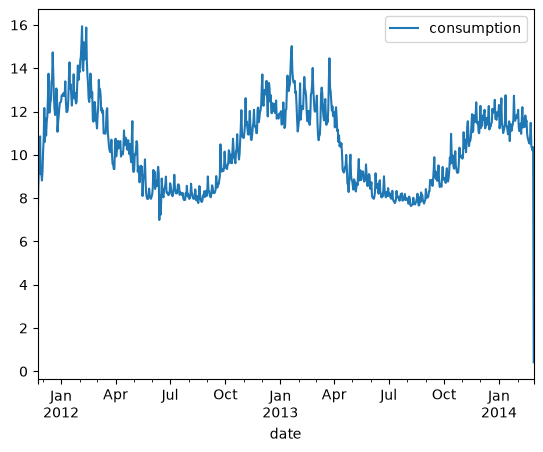

In [59]:
df_avg_consumption.plot(x = 'date', y = 'consumption')

In [60]:
df_avg_consumption['day_of_week'] = df_avg_consumption['date'].dt.dayofweek
df_avg_consumption['day_of_year'] = df_avg_consumption['date'].dt.dayofyear
df_avg_consumption['month'] = df_avg_consumption['date'].dt.month
df_avg_consumption['quarter'] = df_avg_consumption['date'].dt.quarter
df_avg_consumption['year'] = df_avg_consumption['date'].dt.year

df_avg_consumption.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year
0,2011-11-23,6.952692,2,327,11,4,2011
1,2011-11-24,8.536480,3,328,11,4,2011
2,2011-11-25,9.499781,4,329,11,4,2011
3,2011-11-26,10.267707,5,330,11,4,2011
4,2011-11-27,10.850805,6,331,11,4,2011


In [61]:
training_mask = df_avg_consumption['date'] < '2013-07-28'
training_data = df_avg_consumption.loc[training_mask]

print(training_data.shape)

testing_mask = df_avg_consumption['date'] >= '2013-07-28'
testing_data = df_avg_consumption.loc[testing_mask]
print(testing_data.shape)

(613, 7)
(216, 7)


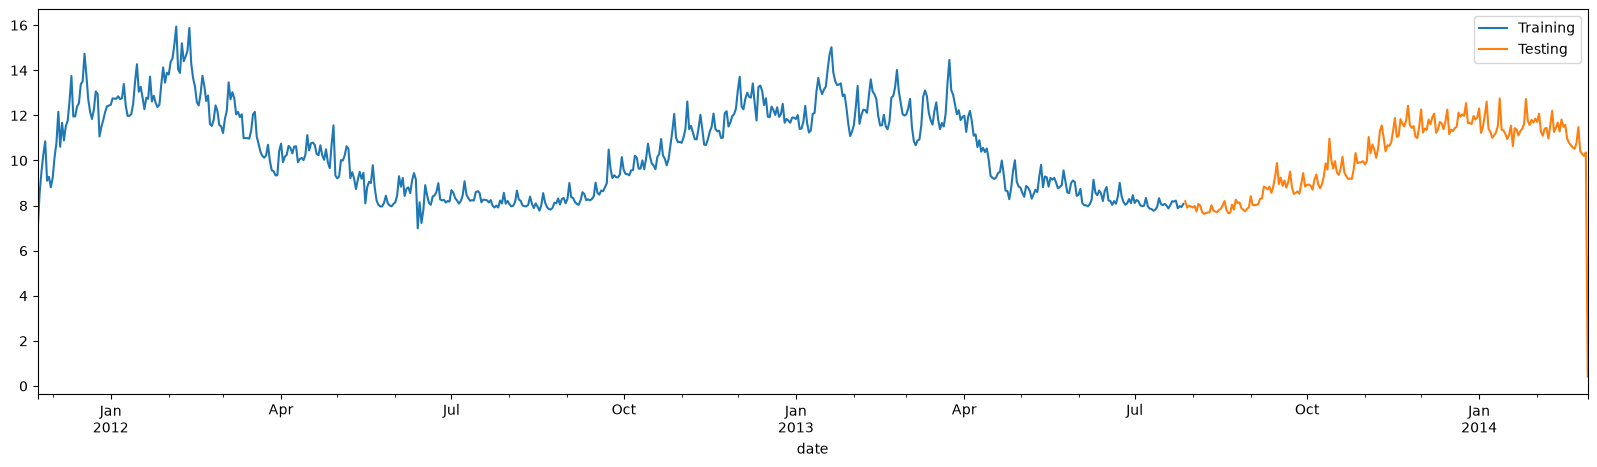

In [62]:
figure, ax = plt.subplots(figsize = (20, 5))
training_data.plot(ax = ax, label = 'Training', x = 'date', y = 'consumption')
testing_data.plot(ax = ax, label = 'Testing', x = 'date', y = 'consumption')
plt.show()

In [ ]:
# Dropping unnecessary 'date' column

training_data = training_data.drop(columns=['date'])
testing_dates = testing_data['date']
testing_data = testing_data.drop(columns = ['date'])

X_train = training_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year']]
y_train = training_data['consumption']

X_test = testing_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year']]
y_test = testing_data['consumption']

In [64]:
# Dropping unnecessary 'date' column
training_data = training_data.drop(columns = ['date'])
testing_dates = testing_data['date']
testing_data = testing_data.drop(columns = ['date'])


X_train = training_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']]
y_train = training_data['consumption']

X_test = testing_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']]
y_test = testing_data['consumption']

KeyError: "['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth'] not in index"

In [ ]:
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = XGBRegressor()
parameters = {
    'max_depth' :  [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 300],
    'colsample_bytree': [0.3] # Khi xây dựng cây, lấy 30% sample build cây thôi
}
grid_search = GridSearchCV(estimator = model , cv = cv_split, param_grid = parameters)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.3], 'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [100, 300]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...test_size=100)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

def evaluate_model(y_test, prediction):
    print(f'MAE: {mean_absolute_error(y_test, prediction)}')
    print(f'MSE: {mean_squared_error(y_test, prediction)}')
    print(f'MAPE: {mean_absolute_percentage_error(y_test, prediction)}')

def plot_predictions(testing_dates, y_test, prediction):
    df_test = pd.DataFrame({'date' : testing_dates, 'actual' : y_test, 'prediction' : prediction})
    figure, ax = plt.subplots(figsize = (10, 5))
    df_test.plot(ax = ax, label = 'Actual', x = 'date', y = 'actual')
    df_test.plot(ax = ax, label = 'Prediction', x = 'date', y = 'prediction')
    plt.legend(['Actual', 'Prediction'])
    plt.show()

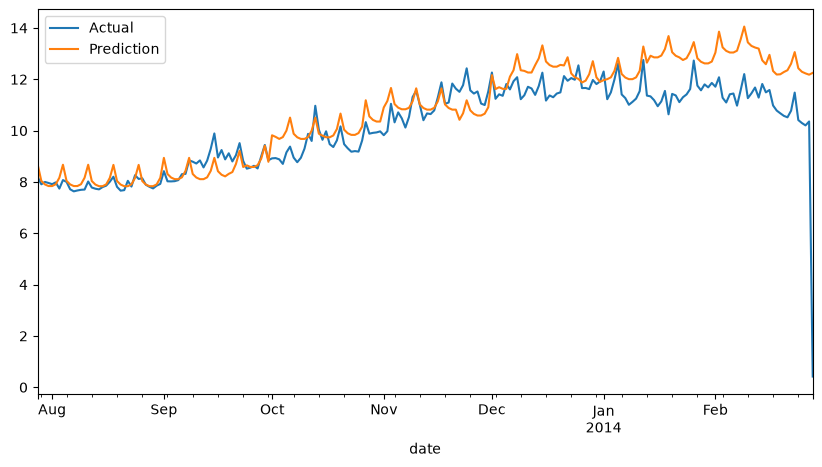

MAE: 0.7682464488327291
MSE: 1.5081916400661224
MAPE: 0.1983756606050506


In [ ]:
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

In [ ]:
df_weather = pd.read_csv('london_weather.csv')
print(df_weather.sum())
print(df_weather.head())

date                3.067536e+11
cloud_cover         8.072000e+04
sunshine            6.673700e+04
global_radiation    1.819594e+06
max_temp            2.359869e+05
mean_temp           1.756327e+05
min_temp            1.159608e+05
precipitation       2.558850e+04
pressure            1.557267e+09
snow_depth          5.280000e+02
dtype: float64
       date  cloud_cover  sunshine  ...  precipitation  pressure  snow_depth
0  19790101          2.0       7.0  ...            0.4  101900.0         9.0
1  19790102          6.0       1.7  ...            0.0  102530.0         8.0
2  19790103          5.0       0.0  ...            0.0  102050.0         4.0
3  19790104          8.0       0.0  ...            0.0  100840.0         2.0
4  19790105          6.0       2.0  ...            0.0  102250.0         1.0

[5 rows x 10 columns]


In [ ]:
# Parsing dates
df_weather['date'] = pd.to_datetime(df_weather['date'], format='%Y%m%d')
df_weather = df_weather.interpolate(method='linear')

# Filling missing values through interpolation

# Enhacing consumption dataset with weather information
df_avg_consumption = df_avg_consumption.merge(df_weather, how='inner', on = 'date')
df_avg_consumption.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,2011-11-23,6.952692,2,327,11,4,2011,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0
1,2011-11-24,8.536480,3,328,11,4,2011,3.0,2.0,35.0,12.5,8.6,3.7,0.2,102710.0,0.0
2,2011-11-25,9.499781,4,329,11,4,2011,3.0,5.0,52.0,14.0,11.0,9.5,0.0,102450.0,0.0
3,2011-11-26,10.267707,5,330,11,4,2011,4.0,0.7,24.0,13.9,10.2,6.3,0.0,102580.0,0.0
4,2011-11-27,10.850805,6,331,11,4,2011,3.0,5.9,55.0,13.2,11.8,9.7,0.0,102130.0,0.0


In [ ]:
# Dropping unnecessary 'date' column
training_data = training_data.drop(columns = ['date'])
testing_dates = testing_data['date']
testing_data = testing_data.drop(columns = ['date'])


X_train = training_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']]
y_train = training_data['consumption']

X_test = testing_data[['day_of_week', 'day_of_year', 'month', 'quarter', 'year', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']]
y_test = testing_data['consumption']

KeyError: "['date'] not found in axis"

In [ ]:
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)